In [1]:
# STEP 1 — Environment and imports

import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("TensorFlow:", tf.__version__)
print("Keras:", getattr(keras, "__version__", "unknown"))
print("GPUs:", tf.config.list_physical_devices("GPU"))


Python executable: d:\Practice Projects\Disease Detection\.venv311\Scripts\python.exe
TensorFlow: 2.21.0
Keras: 3.15.1
GPUs: []


In [2]:
# STEP 2 — Project paths
# Compatible with VS Code / Jupyter on:
# D:/Practice Projects/Disease Detection

HARDCODED_ROOT = Path(r"D:/Practice Projects/Disease Detection")

if HARDCODED_ROOT.exists():
    PROJECT_ROOT = HARDCODED_ROOT
else:
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / "preprocessing" / "splits").exists():
        PROJECT_ROOT = Path.cwd()

SPLIT_DIR = PROJECT_ROOT / "preprocessing" / "splits"
MODEL_DIR = PROJECT_ROOT / "model"
DATASET_DIR = PROJECT_ROOT / "dataset" / "Messidor-2+EyePac_Balanced"
REPORT_DIR = PROJECT_ROOT / "reports" / "severity_analysis"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TEST_CSV = SPLIT_DIR / "test.csv"
FINETUNED_MODEL_PATH = MODEL_DIR / "efficientnetv2_finetuned_best.keras"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TEST_CSV:", TEST_CSV)
print("MODEL:", FINETUNED_MODEL_PATH)
print("DATASET_DIR:", DATASET_DIR)
print("REPORT_DIR:", REPORT_DIR)

if not TEST_CSV.exists():
    raise FileNotFoundError(f"Test CSV not found: {TEST_CSV}")

if not FINETUNED_MODEL_PATH.exists():
    matches = list(MODEL_DIR.rglob("*finetuned*best*.keras"))
    if matches:
        FINETUNED_MODEL_PATH = matches[0]
        print("Resolved model path:", FINETUNED_MODEL_PATH)
    else:
        raise FileNotFoundError("Fine-tuned .keras checkpoint was not found.")


PROJECT_ROOT: D:\Practice Projects\Disease Detection
TEST_CSV: D:\Practice Projects\Disease Detection\preprocessing\splits\test.csv
MODEL: D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
DATASET_DIR: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced
REPORT_DIR: D:\Practice Projects\Disease Detection\reports\severity_analysis


In [4]:
# STEP 3 — Reproducibility and constants (same as notebook 04)

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 5
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Keep numeric labels until the exact dataset mapping is confirmed.
# Same mapping used in 04_efficientnetv2_training.ipynb.
CLASS_NAMES = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
    3: "Class 3",
    4: "Class 4",
}

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)
print("CLASS_NAMES:", CLASS_NAMES)


IMG_SIZE: (224, 224)
BATCH_SIZE: 16
NUM_CLASSES: 5
CLASS_NAMES: {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3', 4: 'Class 4'}


In [5]:
# STEP 4 — Load the trained EfficientNetV2-B0 model (inference only)
# The model is NOT modified and NOT retrained.

final_model = keras.models.load_model(FINETUNED_MODEL_PATH)

print("Loaded model successfully:")
print(FINETUNED_MODEL_PATH)
print("Model name:", getattr(final_model, "name", "unknown"))
print("Input shape:", final_model.input_shape)
print("Output shape:", final_model.output_shape)

if tuple(final_model.output_shape[1:]) != (NUM_CLASSES,):
    raise ValueError(
        f"Expected {NUM_CLASSES} output classes, got {final_model.output_shape}"
    )


Loaded model successfully:
D:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras
Model name: EfficientNetV2B0_EyeDisease
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)


In [6]:
# STEP 5 — Load the exact test dataset (same CSV and column logic as notebook 04)

test_df = pd.read_csv(TEST_CSV)

print("Test rows:", len(test_df))
print("Columns:", list(test_df.columns))
display(test_df.head())


def find_column(df, candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None


PATH_CANDIDATES = [
    "filepath", "file_path", "image_path", "path",
    "image", "filename", "file",
]
LABEL_CANDIDATES = [
    "label", "class", "target", "category", "disease",
]

PATH_COL = find_column(test_df, PATH_CANDIDATES)
LABEL_COL = find_column(test_df, LABEL_CANDIDATES)

if PATH_COL is None or LABEL_COL is None:
    raise ValueError(
        f"Could not identify path/label columns. Columns: {list(test_df.columns)}"
    )

print("Detected path column:", PATH_COL)
print("Detected label column:", LABEL_COL)


Test rows: 270
Columns: ['image_path', 'label']


,image_path,label
0,../dataset/Messidor-2+EyePac_Balanced\3\200604...,3
1,../dataset/Messidor-2+EyePac_Balanced\0\200511...,0
2,../dataset/Messidor-2+EyePac_Balanced\1\200512...,1
3,../dataset/Messidor-2+EyePac_Balanced\1\200604...,1
4,../dataset/Messidor-2+EyePac_Balanced\0\200604...,0


Detected path column: image_path
Detected label column: label


In [7]:
# STEP 5b — Resolve image paths (same candidate order as notebook 04)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def resolve_image_path(value):
    raw = Path(str(value))

    candidates = [
        raw,
        PROJECT_ROOT / raw,
        PROJECT_ROOT / "dataset" / raw,
        PROJECT_ROOT / "datasets" / raw,
        PROJECT_ROOT / "preprocessing" / raw,
    ]

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return str(candidate.resolve())

    name = raw.name
    matches = []
    for root in [PROJECT_ROOT / "dataset", PROJECT_ROOT / "datasets"]:
        if root.exists():
            matches.extend(root.rglob(name))

    if matches:
        return str(matches[0].resolve())

    return str(raw)


test_df = test_df.copy()
test_df["resolved_path"] = test_df[PATH_COL].map(resolve_image_path)

missing = sum(not Path(p).exists() for p in test_df["resolved_path"])
print("Missing test images:", missing)

if missing > 0:
    display(test_df.loc[
        ~test_df["resolved_path"].map(lambda p: Path(p).exists()),
        [PATH_COL, "resolved_path", LABEL_COL]
    ].head(20))
    raise FileNotFoundError("Some test image paths cannot be resolved.")

print("All test image paths resolved.")
print("Label distribution:")
print(test_df[LABEL_COL].value_counts().sort_index())


Missing test images: 0
All test image paths resolved.
Label distribution:
label
0    54
1    54
2    54
3    54
4    54
Name: count, dtype: int64


In [8]:
# STEP 4/5 pipeline — Exact training-notebook image loader and tf.data test set


def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    # IMPORTANT:
    # Keep values in 0..255.
    # EfficientNetV2's built-in preprocessing handles normalization.
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.int32)
    return image, label


def make_dataset(df, training=False):
    paths = df["resolved_path"].values
    labels = df[LABEL_COL].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


test_ds = make_dataset(test_df, training=False)
print(test_ds)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [9]:
# STEP 5 — Verify image preprocessing and class mapping

x_batch, y_batch = next(iter(test_ds))

print("Batch shape:", tuple(x_batch.shape))
print("Label shape:", tuple(y_batch.shape))
print("Pixel dtype:", x_batch.dtype)
print("Pixel min:", float(tf.reduce_min(x_batch)))
print("Pixel max:", float(tf.reduce_max(x_batch)))
print("Pixel mean:", float(tf.reduce_mean(x_batch)))
print("Batch labels:", y_batch.numpy().tolist())

assert tuple(x_batch.shape[1:]) == (224, 224, 3), "Image size must be 224x224x3"
assert x_batch.dtype == tf.float32
assert float(tf.reduce_min(x_batch)) >= 0.0
assert float(tf.reduce_max(x_batch)) <= 255.0 + 1e-3, (
    "Pixels must stay in 0-255 for EfficientNetV2 include_preprocessing=True"
)

detected_labels = sorted(int(x) for x in test_df[LABEL_COL].unique())
print("Detected test labels:", detected_labels)
print("Project CLASS_NAMES:")
for k, v in CLASS_NAMES.items():
    print(f"  {k} -> {v}")

if detected_labels != list(range(NUM_CLASSES)):
    raise ValueError(
        f"Expected labels 0..{NUM_CLASSES-1}, but found {detected_labels}."
    )

print("PASS: Preprocessing and class IDs match notebook 04.")


Batch shape: (16, 224, 224, 3)
Label shape: (16,)
Pixel dtype: <dtype: 'float32'>
Pixel min: 0.0
Pixel max: 255.0
Pixel mean: 135.16848754882812
Batch labels: [3, 0, 1, 1, 0, 2, 1, 0, 4, 2, 1, 2, 1, 2, 1, 4]
Detected test labels: [0, 1, 2, 3, 4]
Project CLASS_NAMES:
  0 -> Class 0
  1 -> Class 1
  2 -> Class 2
  3 -> Class 3
  4 -> Class 4
PASS: Preprocessing and class IDs match notebook 04.


In [10]:
# STEP 6 — Inspect and document the actual 5 class labels
# Search only project files / folders. Do not invent clinical names.

metadata_patterns = (
    "*.md", "*.txt", "*.csv", "*.json", "*.xml", "*.yml", "*.yaml",
    "README*", "readme*", "labels*", "classes*", "mapping*"
)

found_metadata = []
search_roots = [
    DATASET_DIR,
    PROJECT_ROOT / "dataset",
    PROJECT_ROOT / "preprocessing",
    PROJECT_ROOT,
]

for root in search_roots:
    if not root.exists():
        continue
    for pattern in metadata_patterns:
        for f in root.glob(pattern):
            if f.is_file() and "reports" not in f.parts and ".venv" not in str(f):
                found_metadata.append(str(f))

found_metadata = sorted(set(found_metadata))

print("=" * 72)
print("DATASET FOLDER INSPECTION")
print("=" * 72)
print("Dataset directory:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

folder_rows = []
if DATASET_DIR.exists():
    class_folders = sorted(
        [p for p in DATASET_DIR.iterdir() if p.is_dir()],
        key=lambda p: p.name
    )
    print("Class folders:", [p.name for p in class_folders])
    for folder in class_folders:
        n_files = sum(
            1 for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        )
        folder_rows.append({
            "folder_name": folder.name,
            "interpreted_class_id": folder.name,
            "n_images": n_files,
            "has_clinical_name_in_folder": False,
        })
        print(f"  Folder '{folder.name}': {n_files} images")
else:
    print("Dataset directory was not found.")

print("\nCSV label column unique values:", sorted(test_df[LABEL_COL].unique().tolist()))
print("CSV columns:", list(test_df.columns))

severity_like_cols = [
    c for c in test_df.columns
    if any(k in str(c).lower() for k in ["severity", "grade", "percent", "percentage", "score"])
]
print("Severity-like CSV columns:", severity_like_cols if severity_like_cols else "NONE")

print("\nMetadata / documentation files found (project root, dataset, preprocessing):")
if found_metadata:
    for f in found_metadata:
        print(" ", f)
else:
    print("  NONE with class-name or severity documentation.")

folder_df = pd.DataFrame(folder_rows)
display(folder_df)

inventory_df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name_used_in_project": [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    "source_folder_name": [str(i) for i in range(NUM_CLASSES)],
    "documented_clinical_name": ["NOT DOCUMENTED IN PROJECT"] * NUM_CLASSES,
    "severity_percentage_annotation": ["NOT AVAILABLE"] * NUM_CLASSES,
})
display(inventory_df)

inventory_df.to_csv(REPORT_DIR / "class_label_inventory.csv", index=False)
folder_df.to_csv(REPORT_DIR / "dataset_folder_inventory.csv", index=False)
print("Saved class label inventory.")


DATASET FOLDER INSPECTION
Dataset directory: D:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced
Exists: True
Class folders: ['0', '1', '2', '3', '4']
  Folder '0': 360 images
  Folder '1': 360 images
  Folder '2': 360 images
  Folder '3': 360 images
  Folder '4': 360 images

CSV label column unique values: [0, 1, 2, 3, 4]
CSV columns: ['image_path', 'label', 'resolved_path']
Severity-like CSV columns: NONE

Metadata / documentation files found (project root, dataset, preprocessing):
  NONE with class-name or severity documentation.


,folder_name,interpreted_class_id,n_images,has_clinical_name_in_folder
0,0,0,360,False
1,1,1,360,False
2,2,2,360,False
3,3,3,360,False
4,4,4,360,False


,class_id,class_name_used_in_project,source_folder_name,documented_clinical_name,severity_percentage_annotation
0,0,Class 0,0,NOT DOCUMENTED IN PROJECT,NOT AVAILABLE
1,1,Class 1,1,NOT DOCUMENTED IN PROJECT,NOT AVAILABLE
2,2,Class 2,2,NOT DOCUMENTED IN PROJECT,NOT AVAILABLE
3,3,Class 3,3,NOT DOCUMENTED IN PROJECT,NOT AVAILABLE
4,4,Class 4,4,NOT DOCUMENTED IN PROJECT,NOT AVAILABLE


Saved class label inventory.


In [11]:
# STEP 6b — Severity-label availability decision
# Derived from the inspection in the previous cell. Do not invent names.

clinical_tokens = (
    "no dr", "nodr", "mild", "moderate", "severe", "proliferative",
    "npdr", "pdr", "normal", "glaucoma", "cataract",
)

folder_names = [str(x).strip().lower() for x in folder_df["folder_name"].tolist()] if len(folder_df) else []
project_class_names = [CLASS_NAMES[i].strip().lower() for i in range(NUM_CLASSES)]

has_named_clinical_grades = any(
    any(token in name for token in clinical_tokens)
    for name in folder_names + project_class_names
)

has_percentage_or_score_column = bool(severity_like_cols)

doc_name_tokens = ("readme", "mapping", "label", "class", "grade", "severity")
has_mapping_file = any(
    any(tok in Path(f).name.lower() for tok in doc_name_tokens)
    and Path(f).suffix.lower() in {".md", ".txt", ".json", ".yml", ".yaml", ".xml"}
    for f in found_metadata
)

# Integer folders 0-4 plus generic "Class 0" names do not count as severity labels.
SEVERITY_LABELS_AVAILABLE = (
    has_named_clinical_grades
    or has_percentage_or_score_column
    or has_mapping_file
)

print("has_named_clinical_grades:", has_named_clinical_grades)
print("has_percentage_or_score_column:", has_percentage_or_score_column)
print("has_mapping_file:", has_mapping_file)
print("SEVERITY_LABELS_AVAILABLE:", SEVERITY_LABELS_AVAILABLE)
print()
print("Notes:")
print("- Dataset origin folder is named Messidor-2+EyePac_Balanced.")
print("- Kaggle dump path in notebooks contains diabeticretinopathy-messidor-eyepac-preprocessed.")
print("- That origin is consistent with public 5-level DR grading datasets,")
print("  but this project never confirmed or stored that mapping.")
print("- Notebook 04 CLASS_NAMES remain 'Class 0'..'Class 4'.")
print("- No continuous severity percentage exists on any image.")
print("- Therefore this notebook will NOT assign clinical grade names")
print("  and will NOT invent severity percentages.")

availability_df = pd.DataFrame([{
    "severity_labels_available": SEVERITY_LABELS_AVAILABLE,
    "named_clinical_grades_in_project": has_named_clinical_grades,
    "percentage_or_score_column": has_percentage_or_score_column,
    "mapping_file_found": has_mapping_file,
    "labels_actually_present": "integer class IDs 0-4 (folders 0,1,2,3,4)",
    "project_class_names": "Class 0, Class 1, Class 2, Class 3, Class 4",
}])
availability_df.to_csv(REPORT_DIR / "severity_label_availability.csv", index=False)


has_named_clinical_grades: False
has_percentage_or_score_column: False
has_mapping_file: False
SEVERITY_LABELS_AVAILABLE: False

Notes:
- Dataset origin folder is named Messidor-2+EyePac_Balanced.
- Kaggle dump path in notebooks contains diabeticretinopathy-messidor-eyepac-preprocessed.
- That origin is consistent with public 5-level DR grading datasets,
  but this project never confirmed or stored that mapping.
- Notebook 04 CLASS_NAMES remain 'Class 0'..'Class 4'.
- No continuous severity percentage exists on any image.
- Therefore this notebook will NOT assign clinical grade names
  and will NOT invent severity percentages.


In [12]:
# STEP 7 — Generate predictions for all test images

pred_probs = final_model.predict(test_ds, verbose=1)

pred_labels = np.argmax(pred_probs, axis=1).astype(np.int32)
pred_confidence = np.max(pred_probs, axis=1).astype(np.float32)

true_labels = np.concatenate(
    [labels.numpy() for _, labels in test_ds],
    axis=0
).astype(np.int32)

print("True labels shape:", true_labels.shape)
print("Predicted labels shape:", pred_labels.shape)
print("Prediction probabilities shape:", pred_probs.shape)

assert len(true_labels) == len(pred_labels) == len(test_df)
assert pred_probs.shape == (len(test_df), NUM_CLASSES)

accuracy = accuracy_score(true_labels, pred_labels)
correct = int(np.sum(true_labels == pred_labels))
incorrect = int(np.sum(true_labels != pred_labels))

print("Total test images:", len(true_labels))
print("Correct:", correct)
print("Incorrect:", incorrect)
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print()
print("Predicted class counts:")
print(pd.Series(pred_labels).value_counts().sort_index())


17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step
True labels shape: (270,)
Predicted labels shape: (270,)
Prediction probabilities shape: (270, 5)
Total test images: 270
Correct: 147
Incorrect: 123
Accuracy: 0.5444 (54.44%)

Predicted class counts:
0     50
1     13
2    118
3     34
4     55
Name: count, dtype: int64


In [13]:
# STEP 8 — Per-class prediction probabilities

prob_cols = [f"prob_class_{i}" for i in range(NUM_CLASSES)]

predictions_df = pd.DataFrame({
    "image_path": test_df[PATH_COL].values,
    "resolved_path": test_df["resolved_path"].values,
    "true_label": true_labels,
    "true_class_name": [CLASS_NAMES[int(x)] for x in true_labels],
    "predicted_label": pred_labels,
    "predicted_class_name": [CLASS_NAMES[int(x)] for x in pred_labels],
    "is_correct": true_labels == pred_labels,
    "confidence": pred_confidence,
})

for i, col in enumerate(prob_cols):
    predictions_df[col] = pred_probs[:, i]

print("Per-image softmax probabilities (head):")
display(predictions_df.head(10))

mean_prob_by_true = []
for cls in range(NUM_CLASSES):
    mask = true_labels == cls
    row = {
        "true_class": CLASS_NAMES[cls],
        "n_images": int(mask.sum()),
    }
    for j in range(NUM_CLASSES):
        row[f"mean_prob_class_{j}"] = float(pred_probs[mask, j].mean()) if mask.any() else 0.0
    mean_prob_by_true.append(row)

mean_prob_df = pd.DataFrame(mean_prob_by_true)
print("\nMean predicted probability by true class:")
display(mean_prob_df.round(4))

print()
print("Interpretation:")
print("These values are model softmax probabilities over the 5 classes.")
print("They are NOT disease-severity percentages.")


Per-image softmax probabilities (head):


,image_path,resolved_path,true_label,true_class_name,predicted_label,predicted_class_name,is_correct,confidence,prob_class_0,prob_class_1,prob_class_2,prob_class_3,prob_class_4
0,../dataset/Messidor-2+EyePac_Balanced\3\200604...,D:\Practice Projects\Disease Detection\dataset...,3,Class 3,2,Class 2,False,0.712187,0.036161,0.040482,0.712187,0.158583,0.052586
1,../dataset/Messidor-2+EyePac_Balanced\0\200511...,D:\Practice Projects\Disease Detection\dataset...,0,Class 0,0,Class 0,True,0.702192,0.702192,0.171338,0.125609,0.000338,0.000523
2,../dataset/Messidor-2+EyePac_Balanced\1\200512...,D:\Practice Projects\Disease Detection\dataset...,1,Class 1,2,Class 2,False,0.658635,0.064935,0.227250,0.658635,0.037957,0.011223
3,../dataset/Messidor-2+EyePac_Balanced\1\200604...,D:\Practice Projects\Disease Detection\dataset...,1,Class 1,0,Class 0,False,0.629985,0.629985,0.222870,0.145417,0.000940,0.000789
4,../dataset/Messidor-2+EyePac_Balanced\0\200604...,D:\Practice Projects\Disease Detection\dataset...,0,Class 0,0,Class 0,True,0.528783,0.528783,0.274240,0.191267,0.004181,0.001529
5,../dataset/Messidor-2+EyePac_Balanced\2\200511...,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0,Class 0,False,0.434213,0.434213,0.175397,0.388770,0.000441,0.001179
6,../dataset/Messidor-2+EyePac_Balanced\1\200604...,D:\Practice Projects\Disease Detection\dataset...,1,Class 1,2,Class 2,False,0.345560,0.339249,0.311109,0.345560,0.002543,0.001539
7,../dataset/Messidor-2+EyePac_Balanced\0\200604...,D:\Practice Projects\Disease Detection\dataset...,0,Class 0,2,Class 2,False,0.482181,0.440458,0.074722,0.482181,0.001065,0.001574
8,../dataset/Messidor-2+EyePac_Balanced\4\25741_...,D:\Practice Projects\Disease Detection\dataset...,4,Class 4,4,Class 4,True,0.711636,0.000073,0.000097,0.004454,0.283740,0.711636
9,../dataset/Messidor-2+EyePac_Balanced\2\200604...,D:\Practice Projects\Disease Detection\dataset...,2,Class 2,0,Class 0,False,0.463928,0.463928,0.222883,0.304445,0.003679,0.005065



Mean predicted probability by true class:


,true_class,n_images,mean_prob_class_0,mean_prob_class_1,mean_prob_class_2,mean_prob_class_3,mean_prob_class_4
0,Class 0,54,0.4484,0.1724,0.3694,0.0032,0.0066
1,Class 1,54,0.2928,0.2140,0.4781,0.0048,0.0104
2,Class 2,54,0.1695,0.1388,0.6418,0.0341,0.0157
3,Class 3,54,0.0165,0.0211,0.1944,0.4651,0.3029
4,Class 4,54,0.0092,0.0112,0.1007,0.1985,0.6804



Interpretation:
These values are model softmax probabilities over the 5 classes.
They are NOT disease-severity percentages.


In [14]:
# STEP 9 — Analyze model confidence
# Confidence = max softmax probability. This is NOT disease severity.

conf_overall = {
    "n_images": len(pred_confidence),
    "mean_confidence": float(pred_confidence.mean()),
    "median_confidence": float(np.median(pred_confidence)),
    "min_confidence": float(pred_confidence.min()),
    "max_confidence": float(pred_confidence.max()),
    "mean_confidence_correct": float(pred_confidence[true_labels == pred_labels].mean()),
    "mean_confidence_incorrect": float(pred_confidence[true_labels != pred_labels].mean())
    if incorrect else np.nan,
}

print("Overall confidence (max softmax):")
for k, v in conf_overall.items():
    print(f"  {k}: {v}")

print()
print("WARNING: Model confidence is not disease severity.")

conf_rows = []
for cls in range(NUM_CLASSES):
    mask = true_labels == cls
    conf_rows.append({
        "true_class": CLASS_NAMES[cls],
        "n": int(mask.sum()),
        "mean_confidence": float(pred_confidence[mask].mean()),
        "median_confidence": float(np.median(pred_confidence[mask])),
        "mean_confidence_when_correct": float(
            pred_confidence[(true_labels == cls) & (pred_labels == cls)].mean()
        ) if np.any((true_labels == cls) & (pred_labels == cls)) else np.nan,
        "mean_confidence_when_wrong": float(
            pred_confidence[(true_labels == cls) & (pred_labels != cls)].mean()
        ) if np.any((true_labels == cls) & (pred_labels != cls)) else np.nan,
    })

confidence_by_class_df = pd.DataFrame(conf_rows)
display(confidence_by_class_df.round(4))

lowest_df = predictions_df.nsmallest(10, "confidence")[[
    "image_path", "true_class_name", "predicted_class_name", "confidence", "is_correct"
]]
highest_df = predictions_df.nlargest(10, "confidence")[[
    "image_path", "true_class_name", "predicted_class_name", "confidence", "is_correct"
]]

print("\nLowest-confidence predictions:")
display(lowest_df)
print("\nHighest-confidence predictions:")
display(highest_df)


Overall confidence (max softmax):
  n_images: 270
  mean_confidence: 0.6883337497711182
  median_confidence: 0.6878664493560791
  min_confidence: 0.3455601930618286
  max_confidence: 0.9998410940170288
  mean_confidence_correct: 0.7376402616500854
  mean_confidence_incorrect: 0.6294064521789551



,true_class,n,mean_confidence,median_confidence,mean_confidence_when_correct,mean_confidence_when_wrong
0,Class 0,54,0.5802,0.5267,0.5981,0.5579
1,Class 1,54,0.5893,0.5614,0.4874,0.6044
2,Class 2,54,0.6913,0.6757,0.7265,0.5365
3,Class 3,54,0.7632,0.7853,0.8081,0.7216
4,Class 4,54,0.8176,0.8565,0.8526,0.7178



Lowest-confidence predictions:


,image_path,true_class_name,predicted_class_name,confidence,is_correct
6,../dataset/Messidor-2+EyePac_Balanced\1\200604...,Class 1,Class 2,0.345560,False
93,../dataset/Messidor-2+EyePac_Balanced\3\43105_...,Class 3,Class 4,0.387973,False
243,../dataset/Messidor-2+EyePac_Balanced\2\200604...,Class 2,Class 1,0.395109,False
259,../dataset/Messidor-2+EyePac_Balanced\4\40917_...,Class 4,Class 2,0.404288,False
159,../dataset/Messidor-2+EyePac_Balanced\1\200604...,Class 1,Class 1,0.407626,True
249,../dataset/Messidor-2+EyePac_Balanced\0\200604...,Class 0,Class 2,0.410279,False
138,../dataset/Messidor-2+EyePac_Balanced\2\200512...,Class 2,Class 0,0.416787,False
103,../dataset/Messidor-2+EyePac_Balanced\0\200512...,Class 0,Class 0,0.421615,True
67,../dataset/Messidor-2+EyePac_Balanced\2\200604...,Class 2,Class 2,0.426331,True
242,../dataset/Messidor-2+EyePac_Balanced\1\200605...,Class 1,Class 2,0.426976,False



Highest-confidence predictions:


,image_path,true_class_name,predicted_class_name,confidence,is_correct
245,../dataset/Messidor-2+EyePac_Balanced\4\34844_...,Class 4,Class 4,0.999841,True
106,../dataset/Messidor-2+EyePac_Balanced\4\24472_...,Class 4,Class 4,0.999771,True
110,../dataset/Messidor-2+EyePac_Balanced\4\13651_...,Class 4,Class 4,0.999513,True
204,../dataset/Messidor-2+EyePac_Balanced\4\13651_...,Class 4,Class 4,0.999513,True
83,../dataset/Messidor-2+EyePac_Balanced\4\43997_...,Class 4,Class 4,0.999085,True
230,../dataset/Messidor-2+EyePac_Balanced\4\39353_...,Class 4,Class 4,0.997570,True
234,../dataset/Messidor-2+EyePac_Balanced\3\30301_...,Class 3,Class 3,0.997521,True
217,../dataset/Messidor-2+EyePac_Balanced\4\19771_...,Class 4,Class 4,0.996315,True
61,../dataset/Messidor-2+EyePac_Balanced\3\8302_r...,Class 3,Class 4,0.992633,False
39,../dataset/Messidor-2+EyePac_Balanced\4\29058_...,Class 4,Class 4,0.991760,True


In [15]:
# STEP 10 — Does class ordering represent disease severity?
# Investigate ordinal structure of IDs 0-4. This does NOT name clinical grades.

ordinal_distance = np.abs(true_labels - pred_labels)

adjacent_error = (ordinal_distance == 1)
distant_error = (ordinal_distance >= 2)
exact = (ordinal_distance == 0)

n = len(true_labels)
ordinal_summary = pd.DataFrame([{
    "exact_match_n": int(exact.sum()),
    "exact_match_rate": float(exact.mean()),
    "adjacent_error_n": int(adjacent_error.sum()),
    "adjacent_error_rate": float(adjacent_error.mean()),
    "distant_error_n": int(distant_error.sum()),
    "distant_error_rate": float(distant_error.mean()),
    "mean_abs_class_distance": float(ordinal_distance.mean()),
    "median_abs_class_distance": float(np.median(ordinal_distance)),
}])

print("Ordinal distance |true_id - pred_id|:")
display(ordinal_summary.round(4))

error_mask = true_labels != pred_labels
if error_mask.any():
    adj_among_errors = float(adjacent_error[error_mask].mean())
    dist_among_errors = float(distant_error[error_mask].mean())
else:
    adj_among_errors = np.nan
    dist_among_errors = np.nan

print(f"Share of errors that are adjacent (|d|=1): {adj_among_errors:.4f}")
print(f"Share of errors that are distant  (|d|>=2): {dist_among_errors:.4f}")

distance_by_class = []
for cls in range(NUM_CLASSES):
    mask = true_labels == cls
    distance_by_class.append({
        "true_class": CLASS_NAMES[cls],
        "mean_abs_distance": float(ordinal_distance[mask].mean()),
        "exact_rate": float(exact[mask].mean()),
        "adjacent_error_rate": float(adjacent_error[mask].mean()),
        "distant_error_rate": float(distant_error[mask].mean()),
    })

distance_by_class_df = pd.DataFrame(distance_by_class)
print("\nOrdinal error profile by true class:")
display(distance_by_class_df.round(4))

print()
print("How to read this:")
print("- If classes were an ordered severity scale, most mistakes should land")
print("  on neighboring IDs (0<->1, 1<->2, ...) rather than far IDs (0<->4).")
print("- Adjacent errors are consistent with ordinal labels, but they do not")
print("  prove clinical severity names and they do not create a percentage.")
print("- Even if 0-4 were Messidor/ICDR grades, those are discrete stages,")
print("  not a 0-100% severity score.")


Ordinal distance |true_id - pred_id|:


,exact_match_n,exact_match_rate,adjacent_error_n,adjacent_error_rate,distant_error_n,distant_error_rate,mean_abs_class_distance,median_abs_class_distance
0,147,0.5444,89,0.3296,34,0.1259,0.5815,0.0


Share of errors that are adjacent (|d|=1): 0.7236
Share of errors that are distant  (|d|>=2): 0.2764

Ordinal error profile by true class:


,true_class,mean_abs_distance,exact_rate,adjacent_error_rate,distant_error_rate
0,Class 0,0.8333,0.5556,0.0556,0.3889
1,Class 1,0.8704,0.1296,0.8704,0.0000
2,Class 2,0.2963,0.8148,0.0741,0.1111
3,Class 3,0.5185,0.4815,0.5185,0.0000
4,Class 4,0.3889,0.7407,0.1296,0.1296



How to read this:
- If classes were an ordered severity scale, most mistakes should land
  on neighboring IDs (0<->1, 1<->2, ...) rather than far IDs (0<->4).
- Adjacent errors are consistent with ordinal labels, but they do not
  prove clinical severity names and they do not create a percentage.
- Even if 0-4 were Messidor/ICDR grades, those are discrete stages,
  not a 0-100% severity score.


In [16]:
# STEP 11 / 12 — Severity mapping branch
# If valid severity labels exist, compute class-wise severity performance.
# If they do not exist, report that fact explicitly and do not invent percentages.

if SEVERITY_LABELS_AVAILABLE:
    print("Valid named severity labels were found. Computing class-wise performance")
    print("on those labels (still NOT converting them into invented percentages).")
    print()
    for cls in range(NUM_CLASSES):
        total = int(np.sum(true_labels == cls))
        correct_cls = int(np.sum((true_labels == cls) & (pred_labels == cls)))
        print(
            f"{CLASS_NAMES[cls]}: n={total}, "
            f"correct={correct_cls}, "
            f"recall={correct_cls / total if total else 0:.4f}"
        )
else:
    print("=" * 72)
    print("SEVERITY LABEL FINDING")
    print("=" * 72)
    print()
    print("Severity labels are not available in the current dataset.")
    print("Model confidence is not disease severity.")
    print("A separate severity-labelled dataset/model is required.")
    print()
    print("Evidence from this project:")
    print("1. Class folders are named 0, 1, 2, 3, 4 with no clinical names.")
    print("2. split CSVs contain only image_path and integer label.")
    print("3. Notebook 04 maps 0-4 to 'Class 0'..'Class 4' and says")
    print("   mapping is not confirmed.")
    print("4. No README/json/csv in the dataset documents grade names")
    print("   or a severity percentage per image.")
    print("5. Softmax confidence is P(class | image), not % diseased.")
    print()
    print("Therefore this notebook does not invent:")
    print("- Class i -> (i / 4) * 100% severity")
    print("- confidence * 100 as a clinical severity percent")
    print("- unofficial Messidor/ICDR names as if they were in the files")

findings_df = pd.DataFrame([{
    "severity_labels_available": bool(SEVERITY_LABELS_AVAILABLE),
    "statement_1": "Severity labels are not available in the current dataset.",
    "statement_2": "Model confidence is not disease severity.",
    "statement_3": "A separate severity-labelled dataset/model is required.",
    "true_severity_percentage_possible": False,
    "what_model_predicts": "One of 5 discrete class IDs (Class 0-Class 4)",
    "what_model_cannot_predict": (
        "Named clinical grade; continuous severity percentage; "
        "clinically verified disease stage"
    ),
}])
display(findings_df)


SEVERITY LABEL FINDING

Severity labels are not available in the current dataset.
Model confidence is not disease severity.
A separate severity-labelled dataset/model is required.

Evidence from this project:
1. Class folders are named 0, 1, 2, 3, 4 with no clinical names.
2. split CSVs contain only image_path and integer label.
3. Notebook 04 maps 0-4 to 'Class 0'..'Class 4' and says
   mapping is not confirmed.
4. No README/json/csv in the dataset documents grade names
   or a severity percentage per image.
5. Softmax confidence is P(class | image), not % diseased.

Therefore this notebook does not invent:
- Class i -> (i / 4) * 100% severity
- confidence * 100 as a clinical severity percent
- unofficial Messidor/ICDR names as if they were in the files


,severity_labels_available,statement_1,statement_2,statement_3,true_severity_percentage_possible,what_model_predicts,what_model_cannot_predict
0,False,Severity labels are not available in the curre...,Model confidence is not disease severity.,A separate severity-labelled dataset/model is ...,False,One of 5 discrete class IDs (Class 0-Class 4),Named clinical grade; continuous severity perc...


In [17]:
# STEP 13 — Save CSV reports under reports/severity_analysis/

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=list(range(NUM_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    columns=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
)

predictions_df.to_csv(REPORT_DIR / "test_predictions.csv", index=False)
mean_prob_df.to_csv(REPORT_DIR / "mean_probability_by_true_class.csv", index=False)
confidence_by_class_df.to_csv(REPORT_DIR / "confidence_by_class.csv", index=False)
ordinal_summary.to_csv(REPORT_DIR / "ordinal_distance_summary.csv", index=False)
distance_by_class_df.to_csv(REPORT_DIR / "ordinal_distance_by_class.csv", index=False)
cm_df.to_csv(REPORT_DIR / "confusion_matrix.csv")
findings_df.to_csv(REPORT_DIR / "severity_findings.csv", index=False)
lowest_df.to_csv(REPORT_DIR / "lowest_confidence_predictions.csv", index=False)
highest_df.to_csv(REPORT_DIR / "highest_confidence_predictions.csv", index=False)

pd.DataFrame([conf_overall]).to_csv(
    REPORT_DIR / "confidence_overall.csv",
    index=False
)

print("Saved CSV reports to:", REPORT_DIR)
for p in sorted(REPORT_DIR.glob("*.csv")):
    print(" ", p.name)


Saved CSV reports to: D:\Practice Projects\Disease Detection\reports\severity_analysis
  class_label_inventory.csv
  confidence_by_class.csv
  confidence_overall.csv
  confusion_matrix.csv
  dataset_folder_inventory.csv
  highest_confidence_predictions.csv
  lowest_confidence_predictions.csv
  mean_probability_by_true_class.csv
  ordinal_distance_by_class.csv
  ordinal_distance_summary.csv
  severity_findings.csv
  severity_label_availability.csv
  test_predictions.csv


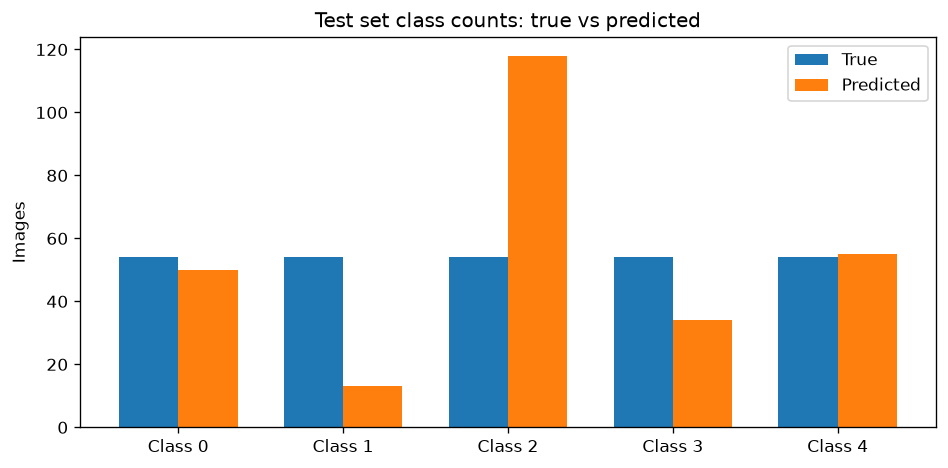

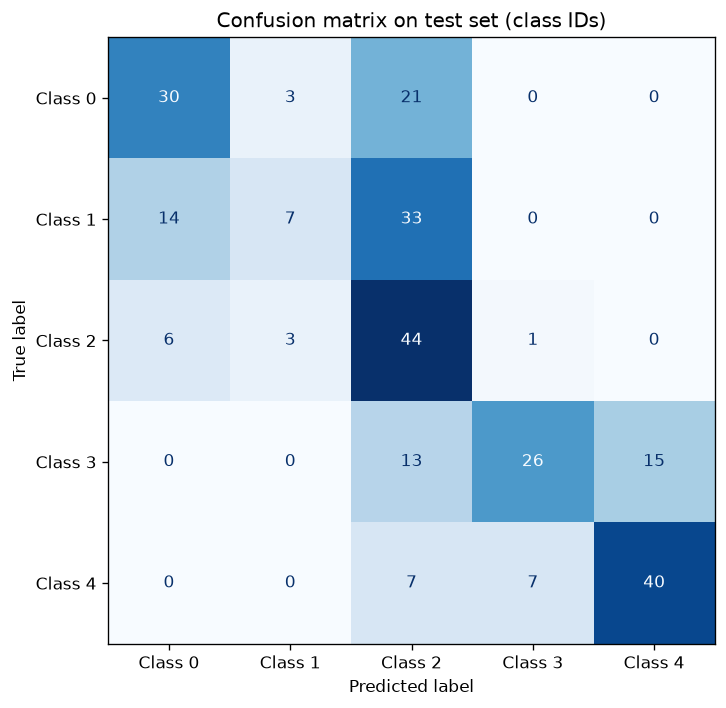

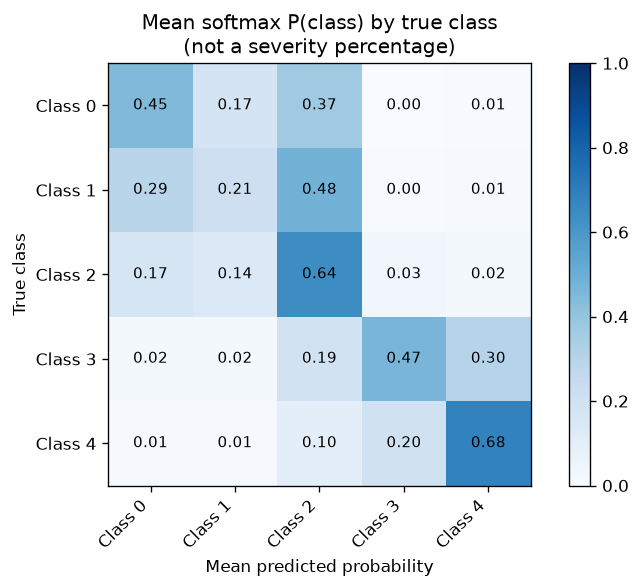

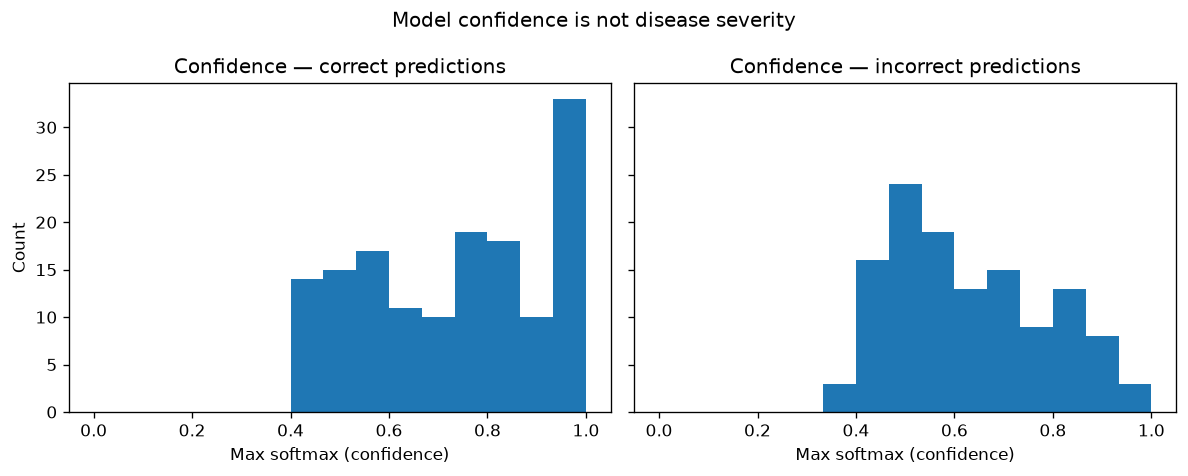

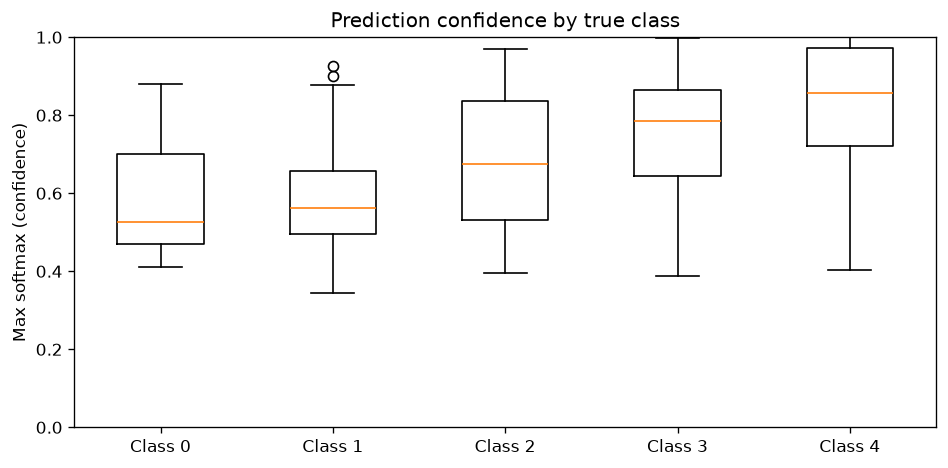

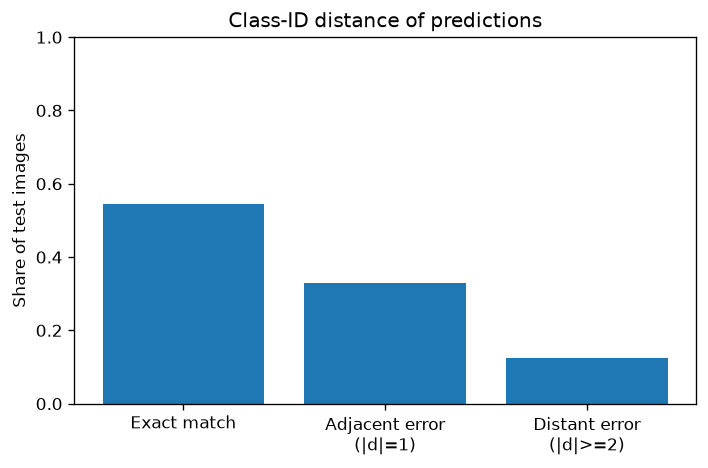

Saved plots to: D:\Practice Projects\Disease Detection\reports\severity_analysis
  class_counts_true_vs_predicted.png
  confidence_boxplot_by_class.png
  confidence_histograms.png
  confusion_matrix.png
  mean_probability_heatmap.png
  ordinal_distance_rates.png


In [18]:
# STEP 14 — Plots (saved under reports/severity_analysis/)

plt.rcParams["figure.dpi"] = 120

# 1. True vs predicted class counts
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(NUM_CLASSES)
true_counts = [(true_labels == i).sum() for i in range(NUM_CLASSES)]
pred_counts = [(pred_labels == i).sum() for i in range(NUM_CLASSES)]
ax.bar(x - 0.18, true_counts, width=0.36, label="True")
ax.bar(x + 0.18, pred_counts, width=0.36, label="Predicted")
ax.set_xticks(x)
ax.set_xticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)])
ax.set_ylabel("Images")
ax.set_title("Test set class counts: true vs predicted")
ax.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "class_counts_true_vs_predicted.png", bbox_inches="tight")
plt.show()
plt.close()

# 2. Confusion matrix (class IDs, not invented severity names)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion matrix on test set (class IDs)")
fig.tight_layout()
fig.savefig(REPORT_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()
plt.close()

# 3. Mean softmax probability heatmap
mean_mat = mean_prob_df[[f"mean_prob_class_{j}" for j in range(NUM_CLASSES)]].values
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(mean_mat, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([CLASS_NAMES[j] for j in range(NUM_CLASSES)], rotation=45, ha="right")
ax.set_yticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)])
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("True class")
ax.set_title("Mean softmax P(class) by true class\n(not a severity percentage)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{mean_mat[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(REPORT_DIR / "mean_probability_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

# 4. Confidence histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].hist(pred_confidence[true_labels == pred_labels], bins=15, range=(0, 1))
axes[0].set_title("Confidence — correct predictions")
axes[0].set_xlabel("Max softmax (confidence)")
axes[0].set_ylabel("Count")
axes[1].hist(pred_confidence[true_labels != pred_labels], bins=15, range=(0, 1))
axes[1].set_title("Confidence — incorrect predictions")
axes[1].set_xlabel("Max softmax (confidence)")
fig.suptitle("Model confidence is not disease severity")
fig.tight_layout()
fig.savefig(REPORT_DIR / "confidence_histograms.png", bbox_inches="tight")
plt.show()
plt.close()

# 5. Confidence boxplot by true class
fig, ax = plt.subplots(figsize=(8, 4))
data = [pred_confidence[true_labels == i] for i in range(NUM_CLASSES)]
ax.boxplot(data)
ax.set_xticklabels([CLASS_NAMES[i] for i in range(NUM_CLASSES)])
ax.set_ylabel("Max softmax (confidence)")
ax.set_title("Prediction confidence by true class")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(REPORT_DIR / "confidence_boxplot_by_class.png", bbox_inches="tight")
plt.show()
plt.close()

# 6. Adjacent vs distant errors
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Exact match", "Adjacent error\n(|d|=1)", "Distant error\n(|d|>=2)"],
    [
        float(exact.mean()),
        float(adjacent_error.mean()),
        float(distant_error.mean()),
    ],
)
ax.set_ylabel("Share of test images")
ax.set_title("Class-ID distance of predictions")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(REPORT_DIR / "ordinal_distance_rates.png", bbox_inches="tight")
plt.show()
plt.close()

print("Saved plots to:", REPORT_DIR)
for p in sorted(REPORT_DIR.glob("*.png")):
    print(" ", p.name)


# Final summary

The next cell writes the project-level conclusions for severity estimation. These conclusions are determined by labels actually stored in this repository, not by unofficial external grade tables.


In [19]:
# STEP 15 — Final summary

print("=" * 72)
print("WHAT THE CURRENT MODEL CAN PREDICT")
print("=" * 72)
print("- A discrete class ID in {0, 1, 2, 3, 4} for a 224x224 RGB fundus image.")
print("- A softmax probability vector over those five classes.")
print("- A confidence value = max(softmax). Useful for ranking uncertain cases.")
print(f"- Test-set exact-class accuracy in this run: {accuracy * 100:.2f}%")
print()

print("=" * 72)
print("WHAT THE CURRENT MODEL CANNOT PREDICT")
print("=" * 72)
print("- A named clinical disease grade (the project never confirmed grade names).")
print("- A disease-severity percentage (no such annotation exists per image).")
print("- Referral / treatment recommendations.")
print("- 'How severe is this case on a 0-100 scale?'")
print()

print("=" * 72)
print("IS TRUE DISEASE SEVERITY PERCENTAGE CURRENTLY POSSIBLE?")
print("=" * 72)
print("No.")
print("Severity labels are not available in the current dataset.")
print("Model confidence is not disease severity.")
print("A separate severity-labelled dataset/model is required.")
print()

print("=" * 72)
print("EXACT NEXT DEVELOPMENT STEP FOR SEVERITY ESTIMATION")
print("=" * 72)
print("1. Obtain (or create) a dataset whose labels are either:")
print("   a) confirmed named DR grades with a written mapping file in the repo,")
print("      e.g. 0=No DR, 1=Mild NPDR, 2=Moderate NPDR, 3=Severe NPDR,")
print("      4=Proliferative DR — only if that mapping is sourced from the")
print("      dataset publisher and stored as project metadata, OR")
print("   b) clinician-labelled continuous / binned severity scores")
print("      (percentage, ETDRS letter score, or an explicit 0-100 scale).")
print("2. Keep those severity targets in a dedicated CSV (do not derive them")
print("   from softmax confidence or from class_id * 25).")
print("3. Train a separate head or model for that target")
print("   (ordinal classification or regression), using a new checkpoint.")
print("4. Do not overwrite efficientnetv2_finetuned_best.keras.")
print("5. Evaluate with metrics that match the target:")
print("   quadratic-weighted kappa / MAE for ordinal grades,")
print("   MAE / MAE% for a true percentage score.")
print()
print("Outputs written to:")
print(REPORT_DIR)


WHAT THE CURRENT MODEL CAN PREDICT
- A discrete class ID in {0, 1, 2, 3, 4} for a 224x224 RGB fundus image.
- A softmax probability vector over those five classes.
- A confidence value = max(softmax). Useful for ranking uncertain cases.
- Test-set exact-class accuracy in this run: 54.44%

WHAT THE CURRENT MODEL CANNOT PREDICT
- A named clinical disease grade (the project never confirmed grade names).
- A disease-severity percentage (no such annotation exists per image).
- Referral / treatment recommendations.
- 'How severe is this case on a 0-100 scale?'

IS TRUE DISEASE SEVERITY PERCENTAGE CURRENTLY POSSIBLE?
No.
Severity labels are not available in the current dataset.
Model confidence is not disease severity.
A separate severity-labelled dataset/model is required.

EXACT NEXT DEVELOPMENT STEP FOR SEVERITY ESTIMATION
1. Obtain (or create) a dataset whose labels are either:
   a) confirmed named DR grades with a written mapping file in the repo,
      e.g. 0=No DR, 1=Mild NPDR, 2=Mode